In [147]:
import jax.numpy as jnp
import jax
from diffrax import (
    diffeqsolve,
    ControlTerm,
    Tsit5,
    MultiTerm,
    ODETerm,
    SaveAt,
    VirtualBrownianTree,
    PIDController,
)
import matplotlib.pyplot as plt

In [148]:
def f(X, t, par):
    beta,gamma,xi = par
    S, I, R = X
    N = S + I + R
    dS = -beta * S * I/N + xi * R
    dI = beta * S * I/N - gamma * I
    dR = gamma * I - xi * R
    return jnp.array([dS, dI, dR])


def h(X, t, par):
    return jnp.array([0.0, 1.0, 0.0]) @ X



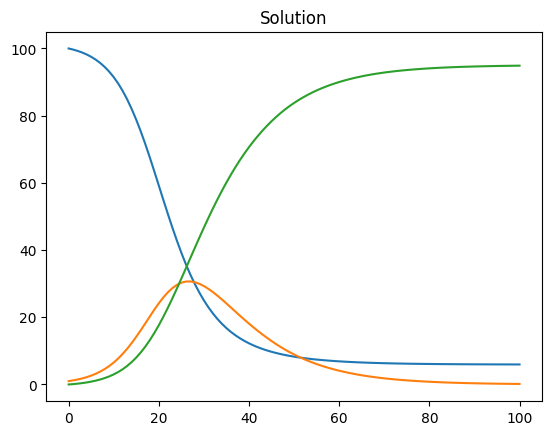

(101,)
(101, 3)


In [149]:
def model(x0, f, ts, params):

    terms = ODETerm(lambda t,x, args: f(x,t,args))
    solver = Tsit5()
    saveat = SaveAt(ts=ts)
    controller = PIDController(rtol=1e-3, atol=1e-3)

    sol = diffeqsolve(
        terms,
        solver,
        ts[0],
        ts[-1],
        dt0=0.01,
        y0=x0,
        saveat=saveat,
        args=params,
        stepsize_controller=controller,
        max_steps=100_000
    )

    return sol.ys

ts = jnp.arange(0,100 + 1, 1)
x0 = jnp.array([100.,1.,0.])
theta = (0.3,0.1,0)
sol = model(x0,f,ts,theta)

plt.title('Solution')
plt.plot(ts,sol)
plt.show()

print(ts.shape)
print(sol.shape)

In [150]:

def lie_derivative(h, f):
    grad_h = jax.grad(h)
    return lambda X, t, par: jnp.dot(grad_h(X, t, par), f(X, t, par))


def iterated_lie_derivative(h, f, order):
    Ds = [h]
    for i in range(1, order):
        Ds.append(lie_derivative(Ds[i - 1], f))

    return Ds

def grad_O(derivatives): 
    jac_funcs = []
    for d in derivatives: 
        jac_funcs.append(jax.grad(d))
    
    
    def jac_eval(X,t,par): 
        vals = jnp.zeros((X.shape[0],X.shape[0]))
        for row in range(len(jac_funcs)): 
            vals = vals.at[row,:].set(jac_funcs[row](X,t,par))

        return vals

    return jac_eval

derivatives = iterated_lie_derivative(h, f, order=3)

jac = grad_O(derivatives)
ranks = jnp.linalg.matrix_rank(jax.vmap(jac,in_axes = (0,0,None))(sol,ts,theta))
indices = jnp.where(ranks == 2,size = 1)
print(indices[0])

[81]


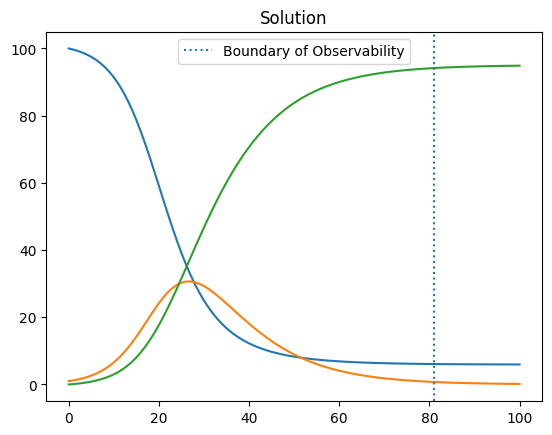

In [151]:
plt.title('Solution')
plt.plot(ts,sol)
plt.axvline(x = indices[0][0],linestyle = 'dotted',label = 'Boundary of Observability')
plt.legend()
plt.show()
